In [2]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

project_root = Path("/home/lestrada/projects/ProDICT")
sys.path.append(str(project_root / "src"))

import prodict.preprocessing as prep
import prodict.entity_classifier_generator as ecg
import prodict.graphs as grph
import prodict.feature_selection as fs
import prodict.model_fit as mf

import sys
import os
import importlib
import joblib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kstest
from scipy import stats

from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV,ElasticNetCV, LogisticRegressionCV
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, classification_report, f1_score, matthews_corrcoef, mean_squared_error,r2_score, roc_auc_score, roc_curve, auc, confusion_matrix, log_loss
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.diagnostic import kstest_normal
from timeit import default_timer as timer
from tqdm import tqdm
from typing import Optional
from joblib import Parallel, delayed
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import io



project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

In [8]:
from pathlib import Path

def load_signature_dict(classifier_signatures_path: str) -> dict:
    """
    Load *_selected_features.txt files into a dictionary.

    Parameters
    ----------
    classifier_signatures_path : str
        Path to the folder containing the signature .txt files.

    Returns
    -------
    dict
        Dictionary where:
        - key = filename without '_selected_features.txt'
        - value = list of lines in the file
    """
    signatures = {}
    folder = Path(classifier_signatures_path)

    txt_files = folder.glob("*_selected_features.txt")
    # use folder.rglob("*_selected_features.txt") if you want subfolders too

    for file in txt_files:
        key = file.name.replace("_selected_features.txt", "")

        with open(file, "r", encoding="utf-8") as f:
            values = [line.strip() for line in f if line.strip()]

        signatures[key] = values

    return signatures

In [46]:
def model_fitting(target_training_df, target_ho_df, target_proteins, output_directory):
    """Fit the final model and evaluate"""
    print("="*80)
    print("Starting model fitting...")
    print("="*80)
    print(f"Using {NESTED_CV_RANDOM_STATE_TRIES} random state tries for nested CV")
    print(f"Using {NESTED_CV_N_SPLITS} splits for nested CV")

    # Reshaping dataset for training and test
    target_training_fs = fs.reshape_df_for_fitting(target_training_df, target_proteins)
    target_test_fs = fs.reshape_df_for_fitting(target_ho_df, target_proteins)

    print(f"Training set shape after feature selection: {target_training_fs.shape}")
    print(f"Test set shape after feature selection: {target_test_fs.shape}")

    # Hyperparameter Selection for Logistic Regression
    try:
        target_nested_cv_results = mf.wrapper_nested_cv(
            target_training_fs,
            random_state_tries=NESTED_CV_RANDOM_STATE_TRIES,
            n_splits=NESTED_CV_N_SPLITS,
            classified_by=CLASSIFIED_BY
        )
        target_nested_hp = mf.nested_cv_hparameters_selection(target_nested_cv_results)
        hyperparameter_C = pd.DataFrame(target_nested_hp).T.sort_values(by='count', ascending=False).index.tolist()[0]
        print(f"Selected hyperparameter C: {hyperparameter_C}")
    except Exception as e:
        print(f"Warning: Hyperparameter selection failed: {e}")
        hyperparameter_C = 1.0  # Default value
        print(f"Using default hyperparameter C: {hyperparameter_C}")

    # Model Fit
    try:
        target_log_reg_model = mf.logistic_regression_ridge(
            target_training_fs,
            hyperparameter_C,
            TARGET_CLASS,
            CLASSIFIED_BY,
            output_directory,
            )

        # Get results
        target_coefficients, target_train_probabilities, target_test_probabilities = mf.logistic_regression_results(
            target_log_reg_model,
            target_training_fs,
            target_test_fs,
            TARGET_CLASS,
            CLASSIFIED_BY,
            output_directory
        )

        # Classification scores
        test_target_scores = mf.classification_scores(target_test_probabilities)

        print("Model training and evaluation completed successfully!")
        return target_log_reg_model, target_coefficients, target_train_probabilities, target_test_probabilities, test_target_scores

    except Exception as e:
        print(f"Error during model fitting: {e}")
        return None, None, None, None, None



In [67]:
import pandas as pd
import numpy as np
from functools import lru_cache

def summarize_predictions_by_threshold(
    nos_probs_results: pd.DataFrame,
    thresholds: dict,
    label_col: str = "code_oncotree",
    custom_label_map: dict | None = None,
    metadata_cols: list[str] | None = None
):
    """
    Returns:
      nos_pred_results: DataFrame with binary predictions (0/1) per thresholded column
      summary_df: DataFrame with TP, TN, FP, FN per prediction column
    """

    if label_col not in nos_probs_results.columns:
        raise ValueError(f"'{label_col}' column not found in nos_probs_results")

    df = nos_probs_results.copy()
    true_labels_series = df[label_col].astype(str).str.strip()
    unique_true_labels = set(true_labels_series.unique())

    pred_cols = [c for c in thresholds.keys() if c in df.columns]
    missing_cols = [c for c in thresholds.keys() if c not in df.columns]
    if missing_cols:
        print(f"Warning: these threshold keys are missing in DataFrame and were skipped: {missing_cols}")

    if metadata_cols is None:
        metadata_cols = [c for c in ["Sample name", "code_oncotree", "TCC", "TCC GROUP"] if c in df.columns]

    # Build binary prediction frame
    nos_pred_results = df[metadata_cols].copy() if metadata_cols else pd.DataFrame(index=df.index)

    # Convert prediction columns to numeric once
    probs = df[pred_cols].apply(pd.to_numeric, errors="coerce")

    def infer_positive_labels_from_key(key: str, true_label_set: set[str]) -> set[str]:
        """
        Infer which true labels compose the key using underscore-joined decomposition.
        Example: PLEMESO_PEMESO -> {'PLEMESO','PEMESO'}
        """
        key = str(key).strip()

        # candidate labels that appear somewhere in key
        candidates = sorted(
            [lbl for lbl in true_label_set if lbl and lbl in key],
            key=len,
            reverse=True
        )

        @lru_cache(maxsize=None)
        def dfs(pos: int):
            if pos == len(key):
                return [()]
            paths = []
            for lbl in candidates:
                if key.startswith(lbl, pos):
                    nxt = pos + len(lbl)
                    if nxt == len(key):
                        paths.append((lbl,))
                    elif key[nxt] == "_":
                        for tail in dfs(nxt + 1):
                            paths.append((lbl,) + tail)
            return paths

        decompositions = dfs(0)
        used = set()
        for path in decompositions:
            used.update(path)

        # fallback to exact key if nothing inferred
        return used if used else {key}

    summary_rows = []

    for col in pred_cols:
        thr = float(thresholds[col])
        y_pred = probs[col].ge(thr).fillna(False)   # >= threshold
        nos_pred_results[col] = y_pred.astype(int)

        # true-positive label set for this prediction column
        if custom_label_map and col in custom_label_map:
            pos_labels = {str(x).strip() for x in custom_label_map[col]}
        else:
            pos_labels = infer_positive_labels_from_key(col, unique_true_labels)

        y_true = true_labels_series.isin(pos_labels)

        TP = int((y_pred & y_true).sum())
        FP = int((y_pred & ~y_true).sum())
        FN = int((~y_pred & y_true).sum())
        TN = int((~y_pred & ~y_true).sum())

        summary_rows.append({
            "Prediction_Column": col,
            "Threshold": thr,
            "Positive_Labels": ", ".join(sorted(pos_labels)),
            "TP": TP,
            "TN": TN,
            "FP": FP,
            "FN": FN,
            "Total": TP + TN + FP + FN
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("Prediction_Column").reset_index(drop=True)
    return nos_pred_results, summary_df


In [50]:
NESTED_CV_RANDOM_STATE_TRIES = 10
NESTED_CV_N_SPLITS = 3


In [4]:
classifier_signatures_path = '/home/lestrada/projects/ProDICT/data/protein_signatures'
training_df_path = '/home/lestrada/projects/ProDICT/data/_cohort_files/initial_training_df.xlsx'
testing_df_path = '/home/lestrada/projects/ProDICT/data/_cohort_files/held_out_df.xlsx'

training_df = pd.read_excel(training_df_path)
test_df = pd.read_excel(testing_df_path)

In [6]:
output_dir = '/home/lestrada/projects/ProDICT/data/07_intensity_classifiers'
CLASSIFIED_BY = 'code_oncotree'

In [41]:
signature_dict = load_signature_dict(classifier_signatures_path)
entities_labels = [key.split("_") for key in signature_dict.keys()]

In [43]:
for entity,key_protein in zip(entities_labels, signature_dict.keys()):
    print(f"Processing {entity}...")
    print(f"Selected features: {key_protein}")

Processing ['THYM']...
Selected features: THYM
Processing ['DSRCT']...
Selected features: DSRCT
Processing ['PLEMESO', 'PEMESO']...
Selected features: PLEMESO_PEMESO
Processing ['ASPS']...
Selected features: ASPS
Processing ['ES']...
Selected features: ES
Processing ['CHDM']...
Selected features: CHDM
Processing ['DFSP']...
Selected features: DFSP
Processing ['ACYC']...
Selected features: ACYC
Processing ['BA', 'ANGS']...
Selected features: BA_ANGS
Processing ['COAD', 'READ', 'COADREAD']...
Selected features: COAD_READ_COADREAD
Processing ['UM']...
Selected features: UM
Processing ['DIFG']...
Selected features: DIFG
Processing ['DDLS']...
Selected features: DDLS
Processing ['BRCA']...
Selected features: BRCA
Processing ['SYNS']...
Selected features: SYNS
Processing ['ACC']...
Selected features: ACC
Processing ['THYC']...
Selected features: THYC
Processing ['SFT']...
Selected features: SFT
Processing ['MRLS']...
Selected features: MRLS
Processing ['LMS', 'ULMS']...
Selected features: LM

In [51]:
for entity,key_protein in zip(entities_labels, signature_dict.keys()):
    print(f"Processing {entity}...")
    print("\n")
    CLASSIFIED_BY = 'code_oncotree'
    TARGET_CLASS = entity
    train_imputed_df = prep.impute_normal_down_shift_distribution(training_df.iloc[:, 4:])
    train_imputed_df= pd.concat([training_df[['Sample name', 'code_oncotree']], train_imputed_df], axis=1)

    test_imputed_df = prep.impute_normal_down_shift_distribution(test_df.iloc[:, 4:])
    test_imputed_df= pd.concat([test_df[['Sample name', 'code_oncotree']], test_imputed_df], axis=1)

    target_training_df =        fs.binary_labeling(train_imputed_df, classified_by=CLASSIFIED_BY, true_class=TARGET_CLASS)
    target_ho_df =              fs.binary_labeling(test_imputed_df, classified_by=CLASSIFIED_BY, true_class=TARGET_CLASS)

    model_results = model_fitting(target_training_df, target_ho_df, signature_dict[key_protein], output_dir)
    print(f"Finished processing {entity}.\n")
    print("\n")


Processing ['THYM']...


(1152, 13069)
(466, 13069)

Number of samples per class:
Classifier
0    1145
1       7
Name: count, dtype: int64


Number of samples per class:
Classifier
0    463
1      3
Name: count, dtype: int64

Starting model fitting...
Using 10 random state tries for nested CV
Using 3 splits for nested CV
Training set shape after feature selection: (1152, 15)
Test set shape after feature selection: (466, 15)
• Running for random_state=0
Inner fold model did not converged.
Inner fold model did not converged.
Inner fold model did not converged.
Inner fold model did not converged.
Inner fold model did not converged.
Inner fold model did not converged.
Inner fold model did not converged.
1 Inner fold best parameter={'C': 10}, Score=0.8320, Outer Validation MCC Score: 1.0000

Inner fold model did not converged.
Inner fold model did not converged.
Inner fold model did not converged.
Inner fold model did not converged.
Inner fold model did not converged.
Inner fold model did n

## External Data Classification 

In [52]:
import pandas as pd
import pickle
import numpy as np
import os
from pathlib import Path
import warnings
from joblib import load

def load_models_from_folder(models_folder_path):
    """
    Load all .pkl model files from a specified folder.

    Parameters:
    models_folder_path (str): Path to folder containing .pkl model files

    Returns:
    dict: Dictionary with model names as keys and loaded models as values
    """
    models = {}
    models_folder = Path(models_folder_path)


    pkl_files = list(models_folder.rglob("*model.pkl"))

    if not pkl_files:
        raise ValueError(f"No .pkl files found in {models_folder_path}")

    print(f"Found {len(pkl_files)} model files:")

    for pkl_file in pkl_files:
        try:
            model = load(pkl_file)
            model_name = pkl_file.name.replace("_log_reg_ridge_model.pkl", "")
            models[model_name] = model
            print(f"  ✓ Loaded: {model_name}")
        except Exception as e:
            print(f"  ✗ Failed to load {pkl_file.name}: {str(e)}")

    return models

def load_excel_data(excel_file_path, sheet_name=None):
    """
    Load data from Excel file.

    Parameters:
    excel_file_path (str): Path to Excel file
    sheet_name (str, optional): Sheet name to load. If None, loads first sheet

    Returns:
    pd.DataFrame: Loaded dataset
    """
    try:
        if sheet_name:
            df = pd.read_excel(excel_file_path, sheet_name=sheet_name)
        else:
            df = pd.read_excel(excel_file_path)

        print(f"Dataset loaded successfully:")
        print(f"  Shape: {df.shape}")
        print(f"  Columns: {list(df.columns[:10])}{'...' if len(df.columns) > 10 else ''}")

        return df

    except Exception as e:
        raise Exception(f"Error loading Excel file: {str(e)}")

def apply_models_to_data(dataset, models, include_probabilities=True, include_predictions=True):
    """
    Apply multiple models to dataset and return predictions/probabilities.

    Parameters:
    dataset (pd.DataFrame): Input dataset with samples as rows
    models (dict): Dictionary of loaded models
    include_probabilities (bool): Whether to include probability columns
    include_predictions (bool): Whether to include prediction columns

    Returns:
    pd.DataFrame: Original dataset with added prediction columns
    """
    results_df = dataset.iloc[:,:4]

    print(f"\nApplying {len(models)} models to dataset...")

    for model_name, model in models.items():
        print(f"\nProcessing model: {model_name}")

        try:
            # Get required features for this model
            required_features = model.feature_names_in_
            print(f"  Required features: {len(required_features)} features")

            # Check if all required features are available in dataset
            missing_features = set(required_features) - set(dataset.columns)
            if missing_features:
                print(f"  ⚠️  Missing features: {missing_features}")
                print(f"  Skipping model {model_name}")
                continue

            # Filter dataset to include only required features
            model_data = dataset[required_features]

            # Check for missing values
            if model_data.isnull().any().any():
                print(f"  ⚠️  Warning: Missing values detected in required features")
                print(f"  Missing value counts:")
                missing_counts = model_data.isnull().sum()
                for feature, count in missing_counts[missing_counts > 0].items():
                    print(f"    {feature}: {count} missing values")

                # skip rows with missing values
                valid_rows = ~model_data.isnull().any(axis=1)
                model_data_clean = model_data[valid_rows]
                print(f"  Using {len(model_data_clean)} samples with complete data")
            else:
                model_data_clean = model_data
                valid_rows = pd.Series([True] * len(dataset))

            if len(model_data_clean) == 0:
                print(f"  ⚠️  No valid samples for model {model_name}")
                continue

            # Make predictions
            if include_predictions:
                predictions = model.predict(model_data_clean)
                model_name = str(model_name).removesuffix("_log_reg_ridge_model")
                pred_column = f"{model_name}"
                results_df.loc[valid_rows, pred_column] = predictions
                print(f"  ✓ Added prediction column: {pred_column}")

            # Get probabilities
            if include_probabilities:
                if hasattr(model, 'predict_proba'):
                    probabilities = model.predict_proba(model_data_clean)

                    # Handle binary vs multiclass
                    if probabilities.shape[1] == 2:
                        # Binary classification - typically use probability of positive class
                        prob_column = f"{model_name}"
                        results_df.loc[valid_rows, prob_column] = probabilities[:, 1]
                        print(f"Added probability column: {prob_column}")
                    else:
                        continue

                else:
                    print(f"Model {model_name} doesn't support probability prediction")

            print(f"  ✓ Successfully processed model {model_name}")

        except Exception as e:
            print(f"  ✗ Error processing model {model_name}: {str(e)}")

    return results_df

def predict_probs(excel_file_path, models_folder_path, output_file_path=None, sheet_name=None):
    """
    Main function to orchestrate the entire process.

    Parameters:
    excel_file_path (str): Path to Excel file with dataset
    models_folder_path (str): Path to folder containing .pkl model files
    output_file_path (str, optional): Path to save results. If None, returns DataFrame
    sheet_name (str, optional): Sheet name to load from Excel

    Returns:
    pd.DataFrame: Dataset with added prediction/probability columns
    """

    # Load dataset
    dataset = load_excel_data(excel_file_path, sheet_name)

    # Load models
    models = load_models_from_folder(models_folder_path)

    if not models:
        raise ValueError("No models specified")

    #Apply models

    results = apply_models_to_data(dataset, models)

    # Save results (optional)
    if output_file_path:
        print(f"\n4. Saving results to {output_file_path}...")
        results.to_excel(output_file_path, index=False)


    new_columns = [col for col in results.columns if col not in dataset.columns]
    print(f"New columns added: {len(new_columns)}")
    for col in new_columns:
        print(f"  - {col}")

    return results


# Additional utility functions:

def get_model_summary(models):
    """
    Print summary information about loaded models.
    """
    print("\n=== Model Summary ===")
    for name, model in models.items():
        print(f"\nModel: {name}")
        print(f"  Type: {type(model).__name__}")
        print(f"  Features required: {len(model.feature_names_in_)}")
        print(f"  Feature names: {list(model.feature_names_in_[:5])}{'...' if len(model.feature_names_in_) > 5 else ''}")
        if hasattr(model, 'classes_'):
            print(f"  Classes: {model.classes_}")

def check_feature_coverage(dataset, models):
    """
    Check which models can be applied to the dataset based on feature availability.
    """
    print("\n=== Feature Coverage Analysis ===")
    dataset_features = set(dataset.columns)

    for model_name, model in models.items():
        required_features = set(model.feature_names_in_)
        missing_features = required_features - dataset_features
        coverage = len(required_features - missing_features) / len(required_features) * 100

        print(f"\nModel: {model_name}")
        print(f"  Feature coverage: {coverage:.1f}% ({len(required_features - missing_features)}/{len(required_features)})")
        if missing_features:
            print(f"  Missing features: {missing_features}")
        else:
            print(f"  ✓ All features available")

# Quick start function for immediate use:
def quick_predict(excel_path, models_folder_path, output_path=None):
    """
    Simplified function for quick predictions.
    """
    return predict_probs(excel_path, models_folder_path, output_path)

In [53]:
def probabilites_calculator (models: dict, test_df: pd.DataFrame) -> pd.DataFrame:
    """
    models: dictionary that contain key: tumor type 'BRCA' ; value: sklearn object of model
    test_df: dataframe for sample prediction, imputed, log10, samples are in rows, proteins in columns. Uses Gene name for proteins.

    prep.impute_normal_down_shift_distribution: function from preprocessing.py that imputes missing values.
    """

    input_df = test_df.copy()
    predictions = {}

    for tumor_entity in models.keys():

        missing_proteins = []

        #Checking that necessary proteins are present and filling with 0 if not.
        for i in models[tumor_entity].feature_names_in_:

            if i not in input_df.columns:
                input_df[i] = 0
                missing_proteins.append(i)

        if not len(missing_proteins):
            print (f'{len(missing_proteins)} proteins added for {tumor_entity}: \n{missing_proteins} \n')

        # Making predictions for a tumor type
        predictions_probs = models[tumor_entity].predict_proba(input_df[models[tumor_entity].feature_names_in_])[:,1]
        predictions[tumor_entity] = predictions_probs

    return pd.DataFrame(predictions)


def generate_prodict_visualization(probabilities_results: pd.DataFrame):

    row = probabilities_results.iloc[0].sort_values()


    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hlines(y=row.index, xmin=0, xmax=row.values, color='lightgrey', lw=2)

    for feature, value in row.items():
        color = 'red' if value > 0.9 else 'steelblue' if value > 0.5 else 'grey'
        ax.plot(value, feature, 'o', color=color, markersize=8)

    # Add threshold lines
    ax.axvline(x=0.5, color='grey', lw=1, linestyle='--')
    ax.axvline(x=0.9, color='black', lw=1, linestyle='--')

    # Axis labels and title
    ax.set_xlabel("Probability")
    #ax.set_title(f"{patient}")

    # Remove the top and right spines (frame)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Keep x and y axis lines
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    # Tight layout for neatness
    plt.tight_layout()

    # Save as SVG in memory
    buf = io.BytesIO()
    plt.savefig(buf, format='svg', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return buf.getvalue().decode('utf-8')


In [54]:
def median_alignement(source_df : pd.DataFrame, target_df : pd.DataFrame,) -> pd.DataFrame:
    """shifts intensities of dataframes

    Args:
        source_df (pd.DataFrame): Dataframe that will set the parameters to be obtained
        target_df (pd.DataFrame): Dataframe that will be shifted

    Returns:
        pd.DataFrame: returns a shifted dataframe to have the same median as the source
    """

    target_df_ = target_df.copy()

    #obtaining missing proteins
    source_proteins = source_df.columns
    target_proteins = target_df.columns
    missing_proteins = list(set(source_proteins) - set(target_proteins))
    missinges_value = round((((len(source_proteins)-len(missing_proteins)) / len(source_proteins))) * 100,1)
    print(f'There are {len(missing_proteins)} protein missing.\nAlignement based on {missinges_value}% of source proteins' )

    #filling missing proteins
    if missing_proteins:
        missing_df = pd.DataFrame(np.nan, index=target_df_.index, columns=missing_proteins)
        target_df_ = pd.concat([target_df_, missing_df], axis=1)

    # adjusting target_df median
    source_median = source_df.median(axis=0).median()
    target_median = target_df_.median(axis=0).median()
    print(f'Median of source data: {source_median}')
    print(f'Median of target data: {target_median}')

    shift_quantity = source_median - target_median
    if shift_quantity>0:
        print(f'Target dataset shift intensity values up by {abs(shift_quantity)}')
        target_df_ = target_df_ + shift_quantity
        print(f'New Median of target dataset: {target_df_.median(axis=0).median()}')
    else:
        print(f'Target dataset shift intensity values down by {abs(shift_quantity)}')
        target_df_ = target_df_ + shift_quantity
        print(f'New Median of target dataset: {target_df_.median(axis=0).median()}')

    # graphical visualization of alignemnet
    source_proteins_median = source_df.median(axis=0)
    target_shifted_proteins_median = target_df_.median(axis=0)
    source, target = source_proteins_median.align(target_shifted_proteins_median, join='outer')
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(source, target, s=1)
    ax.plot([5, 12], [5, 12], 'k-')
    ax.set_xlabel("Source median")
    ax.set_ylabel("Target median")
    plt.show()

    return target_df_

def per_class_confusion_matrices(
    df: pd.DataFrame,
    label_col: str = "code_oncotree",
    threshold: float = 0.5
) -> pd.DataFrame:
    """
    Compute TP, FP, TN, FN for each class column (one-vs-rest).
    """
    results = []

    class_columns = df.columns.drop(label_col)

    for cls in class_columns:
        y_true = df[label_col] == cls
        y_pred = df[cls] > threshold

        TP = (y_pred & y_true).sum()
        FP = (y_pred & ~y_true).sum()
        FN = (~y_pred & y_true).sum()
        TN = (~y_pred & ~y_true).sum()

        results.append({
            "class": cls,
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "TN": TN
        })

    return pd.DataFrame(results).set_index("class")


In [55]:
models_path='/home/lestrada/projects/ProDICT/data/07_intensity_classifiers/'
models = load_models_from_folder(models_path)

# cohort_normalization_parameters_file ='/home/lestrada/projects/ProDICT/data/05_NOS_predictions/cohort_normalization_parameters.pkl'
# norm_param = load(cohort_normalization_parameters_file)

train_df_path = '/home/lestrada/projects/ProDICT/data/_cohort_files/initial_training_df.xlsx'
train_df = pd.read_excel(train_df_path)

Found 24 model files:
  ✓ Loaded: THYC
  ✓ Loaded: SYNS
  ✓ Loaded: DDLS
  ✓ Loaded: DIFG
  ✓ Loaded: THYM
  ✓ Loaded: ARMS
  ✓ Loaded: ERMS
  ✓ Loaded: UM
  ✓ Loaded: COAD_READ_COADREAD
  ✓ Loaded: BRCA
  ✓ Loaded: SFT
  ✓ Loaded: IHCH
  ✓ Loaded: BA_ANGS
  ✓ Loaded: ES
  ✓ Loaded: ACYC
  ✓ Loaded: LMS_ULMS
  ✓ Loaded: CHDM
  ✓ Loaded: ASPS
  ✓ Loaded: DFSP
  ✓ Loaded: ACC
  ✓ Loaded: GIST
  ✓ Loaded: PLEMESO_PEMESO
  ✓ Loaded: MRLS
  ✓ Loaded: DSRCT


In [56]:
models

{'THYC': LogisticRegression(class_weight='balanced', l1_ratio=0, max_iter=10000,
                    penalty='elasticnet', random_state=93, solver='saga'),
 'SYNS': LogisticRegression(C=10, class_weight='balanced', l1_ratio=0, max_iter=10000,
                    penalty='elasticnet', random_state=93, solver='saga'),
 'DDLS': LogisticRegression(C=10, class_weight='balanced', l1_ratio=0, max_iter=10000,
                    penalty='elasticnet', random_state=93, solver='saga'),
 'DIFG': LogisticRegression(C=10, class_weight='balanced', l1_ratio=0, max_iter=10000,
                    penalty='elasticnet', random_state=93, solver='saga'),
 'THYM': LogisticRegression(C=10, class_weight='balanced', l1_ratio=0, max_iter=10000,
                    penalty='elasticnet', random_state=93, solver='saga'),
 'ARMS': LogisticRegression(C=10, class_weight='balanced', l1_ratio=0, max_iter=10000,
                    penalty='elasticnet', random_state=93, solver='saga'),
 'ERMS': LogisticRegression(C=1, c

In [57]:
all_features = [] # all features necessary for prediction
for i in models.keys():
    model = models[i]
    features = model.feature_names_in_.tolist()
    all_features.extend(features)

all_features  = list(set(all_features))
len (all_features)

1104

There are 46 protein missing.
Alignement based on 95.8% of source proteins
Median of source data: 7.240354999999999
Median of target data: 8.11168
Target dataset shift intensity values down by 0.8713250000000006
New Median of target dataset: 7.240354999999999


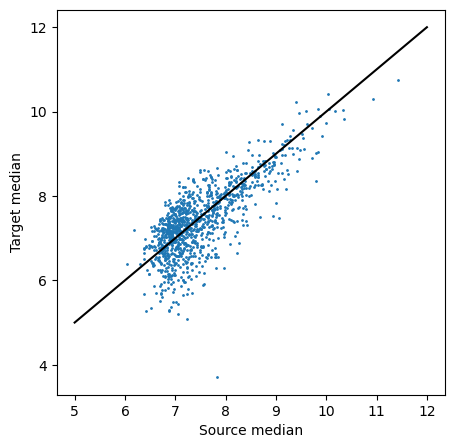

(11857, 153)


In [58]:
BRCA_CPTAC_df = pd.read_csv('/media/kusterlab/internal_projects/active/TOPAS/WP31/Playground/Retrospective_study/2025.09.24_CJ_cptac_brca_paper/preprocessed_fp.csv', index_col='Gene names')
BRCA_CPTAC_df = BRCA_CPTAC_df.T.iloc[:BRCA_CPTAC_df.shape[1]//2,:]

BRCA_CPTAC_aligned_df = median_alignement(train_df[all_features], BRCA_CPTAC_df)

BRCA_CPTAC_df_imputed = prep.impute_normal_down_shift_distribution(BRCA_CPTAC_aligned_df.T).T

In [ ]:
# X = BRCA_CPTAC_df_imputed.drop(columns=["Gene names"], errors="ignore")

# expected = pd.Index(norm_param.feature_names_in_)   # columns used at fit time
# common = expected.intersection(X.columns)           # features present in both

# idx = expected.get_indexer(common)                  # positions in scaler stats

# brca_scaled = X.copy()
# brca_scaled[common] = (X[common] - norm_param.mean_[idx]) / norm_param.scale_[idx]

In [59]:
brca_imputed_df = BRCA_CPTAC_df_imputed.copy()

In [60]:
brca_imputed_df.columns = BRCA_CPTAC_df_imputed.drop(['Gene names'], axis=1, errors='ignore').columns
#scaled_brca = pd.concat([BRCA_CPTAC_df_imputed[['Gene names']].reset_index(drop=True), brca_scaled_imputed], axis=1)

In [61]:
brca_CPTAC_predictions = probabilites_calculator(models, brca_imputed_df)

0 proteins added for THYC: 
[] 

0 proteins added for SYNS: 
[] 

0 proteins added for DDLS: 
[] 

0 proteins added for DIFG: 
[] 

0 proteins added for THYM: 
[] 

0 proteins added for ARMS: 
[] 

0 proteins added for ERMS: 
[] 

0 proteins added for UM: 
[] 

0 proteins added for COAD_READ_COADREAD: 
[] 

0 proteins added for BRCA: 
[] 

0 proteins added for SFT: 
[] 

0 proteins added for IHCH: 
[] 

0 proteins added for BA_ANGS: 
[] 

0 proteins added for ES: 
[] 

0 proteins added for ACYC: 
[] 

0 proteins added for LMS_ULMS: 
[] 

0 proteins added for CHDM: 
[] 

0 proteins added for ASPS: 
[] 

0 proteins added for DFSP: 
[] 

0 proteins added for ACC: 
[] 

0 proteins added for GIST: 
[] 

0 proteins added for PLEMESO_PEMESO: 
[] 

0 proteins added for MRLS: 
[] 

0 proteins added for DSRCT: 
[] 



In [62]:
brca_CPTAC_predictions['code_oncotree'] = 'BRCA'

In [65]:
thresholds = {'SDCA_MYEC': 0.01107619270538752,
 'ACC': 0.8379552538234489,
 'SYNS': 0.9450054643105795,
 'COAD_READ_COADREAD': 0.9687230178869978,
 'GINET': 0.9999999861383868,
 'THYM': 0.9945644606851279,
 'UM': 0.999991879250358,
 'MEL_UM': 0.9961969312610939,
 'ACYC': 0.999998953809026,
 'MPNST': 1.0,
 'BA_ANGS': 0.9950283008606128,
 'LMS_ULMS': 0.9744797360777312,
 'MFH': 0.9155547954635033,
 'BRCA': 0.846132008151978,
 'DDLS': 0.9182392805634169,
 'THYC': 0.9454353117519695,
 'PAAD': 0.4530491652589622,
 'MRLS': 0.9750260783994752,
 'ES': 0.8409176937096031,
 'SFT': 0.9387773423443292,
 'DSRCT': 0.9903930615546578,
 'PANET': 0.9999999999999671,
 'IHCH': 0.9993767281378845,
 'ERMS': 0.9785617488305526,
 'ARMS': 0.8864887037440455,
 'CHDM': 0.3056076620680956,
 'OS': 0.9757624331397176,
 'DIFG': 0.9994197522458776,
 'DFSP': 0.4802323689722501,
 'GIST': 0.8557468634561958,
 'PLEMESO_PEMESO': 0.9482001076744786,
 'ASPS': 0.9581972267504123}

In [68]:
brca_pred_results, confusion_summary = summarize_predictions_by_threshold(
    nos_probs_results=brca_CPTAC_predictions,
    thresholds=thresholds,
    label_col="code_oncotree",
    custom_label_map={
        "PLEMESO_PEMESO": ["PLEMESO", "PEMESO"],
        "COAD_READ_COADREAD": ["COAD", "READ", "COADREAD"],
        "BA_ANGS": ["BA", "ANGS"],
        "LMS_ULMS": ["LMS", "ULMS"]
    }
)

In [70]:
brca_pred_results#.to_excel('/home/lestrada/projects/ProDICT/data/06_external_validation/brca_cptac_predictions.xlsx', index=False)

,code_oncotree,ACC,SYNS,COAD_READ_COADREAD,THYM,UM,ACYC,BA_ANGS,LMS_ULMS,BRCA,...,DSRCT,IHCH,ERMS,ARMS,CHDM,DIFG,DFSP,GIST,PLEMESO_PEMESO,ASPS
0,BRCA,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,BRCA,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,BRCA,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,BRCA,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,BRCA,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,BRCA,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
149,BRCA,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
150,BRCA,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
151,BRCA,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [71]:
confusion_summary#.to_excel('/home/lestrada/projects/ProDICT/data/06_external_validation/brca_cptac_confusion_summary.xlsx', index=False)

,Prediction_Column,Threshold,Positive_Labels,TP,TN,FP,FN,Total
0,ACC,0.837955,ACC,0,153,0,0,153
1,ACYC,0.999999,ACYC,0,153,0,0,153
2,ARMS,0.886489,ARMS,0,153,0,0,153
3,ASPS,0.958197,ASPS,0,153,0,0,153
4,BA_ANGS,0.995028,"ANGS, BA",0,153,0,0,153
5,BRCA,0.846132,BRCA,153,0,0,0,153
6,CHDM,0.305608,CHDM,0,153,0,0,153
7,COAD_READ_COADREAD,0.968723,"COAD, COADREAD, READ",0,153,0,0,153
8,DDLS,0.918239,DDLS,0,153,0,0,153
9,DFSP,0.480232,DFSP,0,153,0,0,153


In [72]:
confusion_summary

,Prediction_Column,Threshold,Positive_Labels,TP,TN,FP,FN,Total
0,ACC,0.837955,ACC,0,153,0,0,153
1,ACYC,0.999999,ACYC,0,153,0,0,153
2,ARMS,0.886489,ARMS,0,153,0,0,153
3,ASPS,0.958197,ASPS,0,153,0,0,153
4,BA_ANGS,0.995028,"ANGS, BA",0,153,0,0,153
5,BRCA,0.846132,BRCA,153,0,0,0,153
6,CHDM,0.305608,CHDM,0,153,0,0,153
7,COAD_READ_COADREAD,0.968723,"COAD, COADREAD, READ",0,153,0,0,153
8,DDLS,0.918239,DDLS,0,153,0,0,153
9,DFSP,0.480232,DFSP,0,153,0,0,153


### 7.2 PROCAN


In [73]:
procan_df = pd.read_excel('/media/kusterlab/internal_projects/active/TOPAS/WP31/Playground/LE_PROdict/paper_classifier_results/05_External_Classifiers/01_ProCan/cohort_1_processed_matrix.xlsx')
procan_protein_mapping = pd.read_csv('/media/kusterlab/users_files/Leonardo_Estrada/01_Projects/Supervised_Classifiers/Final Results/641_all_protein_list_mapping.csv')
procan_protein_mapping.rename(columns={'Unnamed: 0':'ID'}, inplace=True)

In [74]:
#renaming columsn from ID to gene names
mapping_dict = {}
for i in procan_protein_mapping['ID']:
    mapping_dict[i] = procan_protein_mapping.loc[procan_protein_mapping['ID'] == i, 'Gene'].values[0]
procan = procan_df.rename(columns=mapping_dict, inplace=False)

In [75]:
log_10_procan = procan.iloc[:,4:]*np.log10(2)
log_10_procan

,SRP14,ZFP91,Q8N697,RPL4,CLPX,UNC119B,RBM42,RCC2,P17542,MSL1,...,Q96DU7,P56645,P16109,DMRT2,PUS3,Q969E3,CDC45,CCDC175,Q92963,STAT5B
0,1.586351,NaN,NaN,2.273023,NaN,NaN,NaN,1.652016,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.704282,NaN,NaN
1,1.328197,0.542825,NaN,2.021066,NaN,NaN,NaN,1.474271,NaN,NaN,...,NaN,NaN,NaN,2.834161,NaN,NaN,NaN,1.857073,NaN,NaN
2,1.446582,NaN,NaN,2.188924,NaN,0.596342,NaN,1.190284,NaN,NaN,...,NaN,NaN,NaN,2.619124,NaN,NaN,NaN,NaN,NaN,NaN
3,1.366256,NaN,NaN,2.011548,NaN,NaN,NaN,1.335358,NaN,NaN,...,NaN,NaN,1.506511,2.766189,NaN,NaN,NaN,1.724278,NaN,0.993068
4,1.153478,NaN,NaN,1.881288,NaN,NaN,NaN,1.289985,NaN,NaN,...,NaN,NaN,NaN,2.631881,NaN,NaN,NaN,1.694063,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,2.178205,0.868357,NaN,2.572807,1.027778,0.936137,1.059284,1.789282,NaN,0.478047,...,NaN,NaN,NaN,2.077115,NaN,NaN,NaN,NaN,NaN,NaN
1256,1.880608,NaN,NaN,2.371042,0.564727,1.044769,0.848876,1.680110,NaN,NaN,...,NaN,NaN,NaN,2.721606,NaN,NaN,NaN,1.610811,NaN,NaN
1257,2.076735,0.806207,NaN,2.361112,0.561266,1.034164,0.942035,1.709622,NaN,0.161169,...,NaN,NaN,0.821385,2.211762,NaN,NaN,NaN,1.308161,NaN,1.099981
1258,1.896633,NaN,NaN,2.347935,NaN,1.133219,0.491083,1.510796,NaN,NaN,...,NaN,NaN,NaN,2.361427,NaN,NaN,NaN,1.401332,NaN,1.184884


In [76]:
metadata = procan.iloc[:,:4]
prot_intensities = procan.iloc[:,4:]

index_cancer_samples = metadata[metadata['Cancer type'] != 'Normal'].index
procan_cancer_intensities = prot_intensities.filter(items=list(index_cancer_samples), axis=0)
procan_cancer_metadata = metadata['Cancer subtype'][index_cancer_samples]

In [77]:
procan_metadata_to_oncotree = {'Breast_carcinoma':'BRCA', 'Cholangiocarcinoma':'IHCH','Colorectal_adenocarcinoma': 'COAD',
                               'Cutaneous_melanoma':'MEL', 'Cutaneous_squamous_cell_carcinoma': 'CSCC', 'Ewing_sarcoma':'ES',
                               'Glioblastoma':'DIFG', 'Leiomyosarcoma':'LMS', 'Liposarcoma':'DDLS', 'Osteosarcoma':'OS', 'Rhabdomyosarcoma':'RMS',
                               'Synovial_sarcoma': 'SYNS' }

metadata["code_oncotree"] = metadata["Cancer subtype"].replace(procan_metadata_to_oncotree)


In [78]:
display(metadata.head())
display(procan_cancer_intensities.head())

,SampleID,Cancer type,Tissue type,Cancer subtype,code_oncotree
0,00J63,Normal,Adipose tissue,Normal_adipose_tissue,Normal_adipose_tissue
1,00J5Z,Normal,Adipose tissue,Normal_adipose_tissue,Normal_adipose_tissue
2,00G65,Normal,Adipose tissue,Normal_adipose_tissue,Normal_adipose_tissue
3,00G5X,Normal,Adipose tissue,Normal_adipose_tissue,Normal_adipose_tissue
4,00G6X,Normal,Adipose tissue,Normal_adipose_tissue,Normal_adipose_tissue


,SRP14,ZFP91,Q8N697,RPL4,CLPX,UNC119B,RBM42,RCC2,P17542,MSL1,...,Q96DU7,P56645,P16109,DMRT2,PUS3,Q969E3,CDC45,CCDC175,Q92963,STAT5B
12,5.455684,NaN,NaN,7.333792,NaN,NaN,NaN,5.032627,NaN,NaN,...,NaN,NaN,NaN,10.092037,NaN,NaN,NaN,5.244786,NaN,NaN
13,5.511908,NaN,NaN,7.519434,NaN,NaN,NaN,4.608968,NaN,NaN,...,NaN,NaN,NaN,10.535435,NaN,NaN,NaN,NaN,NaN,NaN
14,4.775571,NaN,NaN,7.203134,NaN,NaN,NaN,4.482448,NaN,NaN,...,NaN,NaN,NaN,9.402898,NaN,NaN,NaN,5.301922,NaN,NaN
15,5.049532,NaN,NaN,7.499714,NaN,NaN,NaN,4.452530,NaN,NaN,...,NaN,NaN,5.140825,10.222162,NaN,NaN,NaN,5.963697,NaN,NaN
16,5.333223,NaN,NaN,7.446016,NaN,NaN,NaN,4.795310,NaN,NaN,...,NaN,NaN,NaN,10.500287,1.8747,NaN,NaN,5.672365,NaN,NaN


There are 220 protein missing.
Alignement based on 80.1% of source proteins
Median of source data: 7.240354999999999
Median of target data: 3.328461953559823
Target dataset shift intensity values up by 3.911893046440176
New Median of target dataset: 7.240354999999999


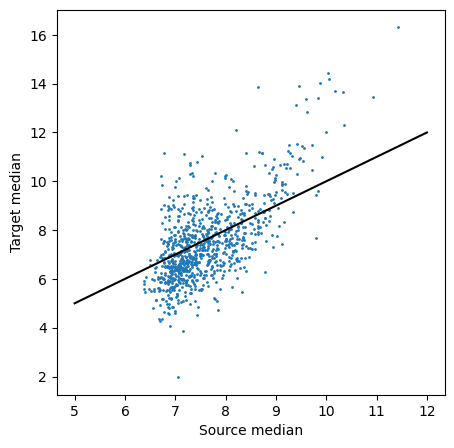

In [89]:
procan_log2_adjusted_df = median_alignement(train_df[all_features], prot_intensities)

In [90]:
procan_log2_imp = prep.impute_normal_down_shift_distribution(procan_log2_adjusted_df.T).T

(9322, 1260)


In [ ]:
# procan_log2_df = procan_log2_imp.drop(columns=["Gene names"], errors="ignore")

# expected = pd.Index(norm_param.feature_names_in_)   # columns used at fit time
# common = expected.intersection(procan_log2_df.columns)           # features present in both

# idx = expected.get_indexer(common)                  # positions in scaler stats

# procan_log2_imp_scaled = procan_log2_df.copy()
# procan_log2_imp_scaled[common] = (procan_log2_df[common] - norm_param.mean_[idx]) / norm_param.scale_[idx]


NameError: name 'norm_param' is not defined

In [91]:
procan_class_probabilities = probabilites_calculator(models, procan_log2_imp)

0 proteins added for THYC: 
[] 

0 proteins added for SYNS: 
[] 

0 proteins added for DDLS: 
[] 

0 proteins added for DIFG: 
[] 

0 proteins added for THYM: 
[] 

0 proteins added for ARMS: 
[] 

0 proteins added for ERMS: 
[] 

0 proteins added for UM: 
[] 

0 proteins added for COAD_READ_COADREAD: 
[] 

0 proteins added for BRCA: 
[] 

0 proteins added for SFT: 
[] 

0 proteins added for IHCH: 
[] 

0 proteins added for BA_ANGS: 
[] 

0 proteins added for ES: 
[] 

0 proteins added for ACYC: 
[] 

0 proteins added for LMS_ULMS: 
[] 

0 proteins added for CHDM: 
[] 

0 proteins added for ASPS: 
[] 

0 proteins added for DFSP: 
[] 

0 proteins added for ACC: 
[] 

0 proteins added for GIST: 
[] 

0 proteins added for PLEMESO_PEMESO: 
[] 

0 proteins added for MRLS: 
[] 

0 proteins added for DSRCT: 
[] 



In [92]:
procan_probabilities_meta = pd.concat([metadata[['Cancer type', 'code_oncotree']], procan_class_probabilities], axis=1)

In [93]:
procan_probabilities_meta = procan_probabilities_meta[procan_probabilities_meta['Cancer type'] != 'Normal']

In [94]:
procan_probabilities_meta.drop(columns=['Cancer type'], inplace=True)

In [95]:
procan_predictions_meta, procan_confusion_summary = summarize_predictions_by_threshold(
    nos_probs_results=procan_probabilities_meta,
    thresholds=thresholds,
    label_col="code_oncotree",
    custom_label_map={
        "PLEMESO_PEMESO": ["PLEMESO", "PEMESO"],
        "COAD_READ_COADREAD": ["COAD", "READ", "COADREAD"],
        "BA_ANGS": ["BA", "ANGS"],
        "LMS_ULMS": ["LMS", "ULMS"]
    }
)

In [96]:
procan_probabilities_meta[procan_probabilities_meta['BRCA'] > 0.86].value_counts(subset=['code_oncotree'])

code_oncotree                   
BRCA                                74
Head_and_neck_squamous               4
DDLS                                 3
High_grade_serous_ovary              3
CSCC                                 2
Germ_cell_testis                     2
Basal_cell_skin_carcinoma            2
Non_small_cell_lung_squamous         2
OS                                   1
Small_cell_lung_cancer               1
SYNS                                 1
Pancreatic_ductal_adenocarcinoma     1
Oesophageal_squamous                 1
MEL                                  1
Non_small_cell_lung_adeno            1
Mixed_mullerian_ovary                1
Fibrosarcoma                         1
COAD                                 1
Transitional_cell_bladder            1
Name: count, dtype: int64

In [97]:
procan_confusion_summary#.to_excel('/media/kusterlab/users_files/Leonardo_Estrada/01_Projects/Supervised_Classifiers/Final Results/63_procan_lg10_confusion_summary.xlsx', index=False)

,Prediction_Column,Threshold,Positive_Labels,TP,TN,FP,FN,Total
0,ACC,0.837955,ACC,0,750,16,0,766
1,ACYC,0.999999,ACYC,0,677,89,0,766
2,ARMS,0.886489,ARMS,0,687,79,0,766
3,ASPS,0.958197,ASPS,0,763,3,0,766
4,BA_ANGS,0.995028,"ANGS, BA",0,747,19,0,766
5,BRCA,0.846132,BRCA,74,647,29,16,766
6,CHDM,0.305608,CHDM,0,750,16,0,766
7,COAD_READ_COADREAD,0.968723,"COAD, COADREAD, READ",29,700,17,20,766
8,DDLS,0.918239,DDLS,13,705,41,7,766
9,DFSP,0.480232,DFSP,0,531,235,0,766


In [ ]:
procan_confusion_summary#.to_excel('/media/kusterlab/users_files/Leonardo_Estrada/01_Projects/Supervised_Classifiers/Final Results/63_procan_lg10_confusion_summary.xlsx', index=False)

,Prediction_Column,Threshold,Positive_Labels,TP,TN,FP,FN,Total
0,ACC,0.837955,ACC,0,765,1,0,766
1,ACYC,0.999999,ACYC,0,491,275,0,766
2,ARMS,0.886489,ARMS,0,707,59,0,766
3,ASPS,0.958197,ASPS,0,721,45,0,766
4,BA_ANGS,0.995028,"ANGS, BA",0,710,56,0,766
5,BRCA,0.846132,BRCA,90,401,275,0,766
6,CHDM,0.305608,CHDM,0,766,0,0,766
7,COAD_READ_COADREAD,0.968723,"COAD, COADREAD, READ",35,693,24,14,766
8,DDLS,0.918239,DDLS,13,717,29,7,766
9,DFSP,0.480232,DFSP,0,479,287,0,766
